# Activity 4 — Search for Sentinel-2 imagery with STAC

**Learning objective:** Use the Area of Interest (AOI), a date range and a cloud-cover threshold to find Sentinel-2 imagery.

This activity follows the same structure used in the existing invasive-species prediction notebook.

## 1. Import the libraries

Python libraries give us specialised tools. Here we use:

- `geopandas` for the AOI
- `pystac_client` to search a STAC catalogue
- `odc.stac` to load satellite data later
- `folium` and `matplotlib` for visualisation

In [1]:
from pystac_client import Client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import folium
import matplotlib.pyplot as plt

import odc.geo.xr  # activates .odc accessor

## 2. Connect to the Sentinel-2 catalogue

In [2]:
STAC_URL = "https://earth-search.aws.element84.com/v1"

catalog = Client.open(STAC_URL)

print("Connected to:", STAC_URL)

Connected to: https://earth-search.aws.element84.com/v1


## 3. Load the workshop AOI

AOI CRS: EPSG:4326
Number of AOI features: 3296
Geometry type(s):
Point    3296
Name: count, dtype: int64


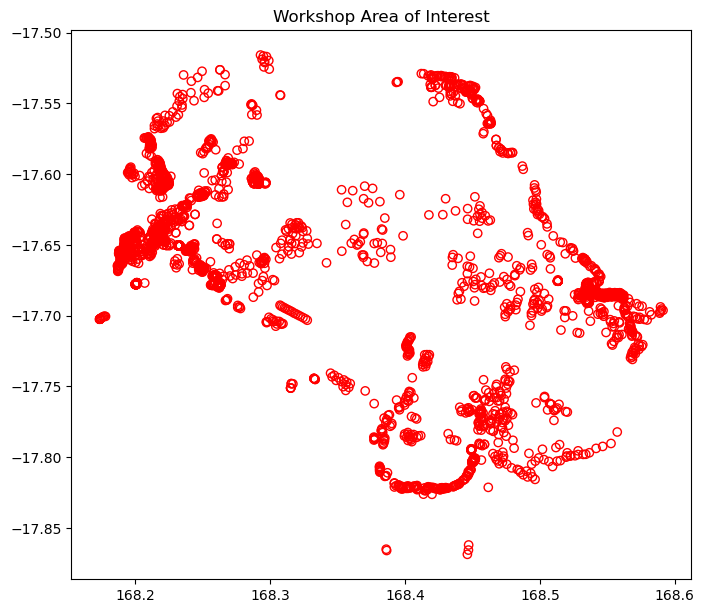

In [4]:
AOI_PATH = "AOI/Merged_CleanV3.geojson"

aoi_gdf = gpd.read_file(AOI_PATH)

print("AOI CRS:", aoi_gdf.crs)
print("Number of AOI features:", len(aoi_gdf))
print("Geometry type(s):")
print(aoi_gdf.geometry.geom_type.value_counts())

aoi_gdf.plot(edgecolor="red", facecolor="none", figsize=(8, 8))
plt.title("Workshop Area of Interest")
plt.show()

## 4. Prepare the bounding box

STAC searches require geographic longitude/latitude coordinates.  
If the AOI is not already in EPSG:4326, reproject it before creating the bounding box.

In [5]:
aoi_wgs84 = aoi_gdf.to_crs("EPSG:4326")
bbox = aoi_wgs84.total_bounds.tolist()

print("Bounding box [min lon, min lat, max lon, max lat]:")
print(bbox)

Bounding box [min lon, min lat, max lon, max lat]:
[168.173248, -17.8687435, 168.5913305, -17.5159283962943]


## 5. Search for Sentinel-2 scenes

In [6]:
# Change these two workshop parameters
DATE_RANGE = "2025-05-01/2025-11-30"
MAX_CLOUD = 25

items = catalog.search(
    collections=["sentinel-2-c1-l2a"],
    bbox=bbox,
    datetime=DATE_RANGE,
    query={"eo:cloud_cover": {"lt": MAX_CLOUD}},
).item_collection()

print(f"Found {len(items)} Sentinel-2 items")

Found 67 Sentinel-2 items


In [7]:
# Inspect the first few results
for item in items[:10]:
    print(
        item.id,
        "| Date:", item.datetime.date(),
        "| Cloud:", item.properties.get("eo:cloud_cover")
    )

S2C_T58KHF_20251130T230027_L2A | Date: 2025-11-30 | Cloud: 5.519695
S2C_T59KKA_20251130T230027_L2A | Date: 2025-11-30 | Cloud: 3.777599
S2B_T58KHF_20251125T230011_L2A | Date: 2025-11-25 | Cloud: 12.70041
S2B_T59KKA_20251125T230011_L2A | Date: 2025-11-25 | Cloud: 12.979865
S2C_T58KHF_20251113T230915_L2A | Date: 2025-11-13 | Cloud: 16.955361
S2C_T59KKA_20251113T230915_L2A | Date: 2025-11-13 | Cloud: 21.157239
S2B_T58KHF_20251105T230014_L2A | Date: 2025-11-05 | Cloud: 6.392944
S2B_T59KKA_20251105T230014_L2A | Date: 2025-11-05 | Cloud: 6.214135
S2C_T58KHF_20251031T230031_L2A | Date: 2025-10-31 | Cloud: 11.242925
S2C_T59KKA_20251031T230031_L2A | Date: 2025-10-31 | Cloud: 9.157229


### Participant exercise

Change `MAX_CLOUD` from 25 to 10 and run the search again.

**Question:** Did the number of available scenes increase or decrease? Why?